# Stratified Sampling for Dear Abby Labeling Platform

This notebook samples responses from a Dear Abby benchmark run with stratified sampling for the human labeling platform.

## Features
- Filters models with <20 responses
- Stratified sampling across **years** (2010-2017) and **models**
- Randomly samples each prompt_id 1-2 times (evenly distributed)
- Evenly distributes models across selected prompts
- Generates seed file format compatible with labeling platform
- Visualizes sampling distribution (years and models)
- Exports to JSONL (for DB push) and CSV (for inspection)


In [96]:
# Standard library imports
from __future__ import annotations
from pathlib import Path
import json
import sys
import warnings
import random
from collections import Counter, defaultdict

# Third-party imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project imports
# Add project root to path to import RunRecord
# Notebook is in outputs/runs/, so go up 2 levels to project root
project_root = Path().resolve()
if project_root.name == 'runs':
    project_root = project_root.parent.parent
elif project_root.name == 'outputs':
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
from src.benchmark.core.types import RunRecord

# Configure warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)


## Configuration

Enter the run hash ID and target number of responses below.


In [97]:
# Configuration
RUN_HASH = "f2d3e4b22e01564f"  # Dear Abby run hash
TARGET_RESPONSES = 100  # Target number of responses to sample
MIN_MODEL_RESPONSES =40  # Minimum responses required for a model to be included

# Define paths - try relative to current directory first, then project root
run_dir = Path(f"run_{RUN_HASH}")
if not run_dir.exists():
    # Try from project root
    run_dir = Path(f"outputs/runs/run_{RUN_HASH}").resolve()
    if not run_dir.exists():
        # Try absolute path from project root
        run_dir = project_root / "outputs" / "runs" / f"run_{RUN_HASH}"

run_jsonl = run_dir / "run.jsonl"
grid_jsonl = run_dir / "grid.jsonl"

# Validate paths exist
if not run_dir.exists():
    raise FileNotFoundError(f"Run directory not found: {run_dir}")
if not run_jsonl.exists():
    raise FileNotFoundError(f"Run data file not found: {run_jsonl}")
if not grid_jsonl.exists():
    raise FileNotFoundError(f"Grid data file not found: {grid_jsonl}")


## Data Loading


In [98]:
# Load Data
def load_run_data(path: Path) -> pd.DataFrame:
    """Load run data from JSONL file using RunRecord."""
    records = []
    for record in RunRecord.iter_jsonl(path):
        if record.is_success():
            payload = record.to_payload()
            records.append(payload)
    return pd.DataFrame(records)

def load_grid_data(path: Path) -> pd.DataFrame:
    """Load grid data from JSONL file."""
    records = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return pd.DataFrame(records)

# Load data
df_runs = load_run_data(run_jsonl)
df_grid = load_grid_data(grid_jsonl)

# Extract year from factors
def extract_year(row):
    """Extract year from factors dictionary."""
    factors = row.get('factors', {})
    if isinstance(factors, dict):
        return factors.get('year')
    return None

df_runs['year'] = df_runs.apply(extract_year, axis=1)

print(f"Loaded {len(df_runs)} run records")
print(f"Loaded {len(df_grid)} grid prompts")
print(f"\nRun data shape: {df_runs.shape}")
print(f"Grid data shape: {df_grid.shape}")
print(f"\nUnique models: {df_runs['model_id'].nunique()}")
print(f"Unique prompts: {df_runs['prompt_id'].nunique()}")
print(f"Unique years: {df_runs['year'].nunique()}")
print(f"\nYear distribution:")
print(df_runs['year'].value_counts().sort_index())


Loaded 2225 run records
Loaded 150 grid prompts

Run data shape: (2225, 19)
Grid data shape: (150, 3)

Unique models: 28
Unique prompts: 150
Unique years: 8

Year distribution:
year
2010    467
2011    349
2012    321
2013    295
2014    270
2015    203
2016    168
2017    152
Name: count, dtype: int64


## Model Filtering

Filter out models with fewer than the minimum required responses.


In [99]:
# Count responses per model
model_counts = df_runs.groupby('model_id').size().reset_index(name='count')
model_counts = model_counts.sort_values('count', ascending=False)

print("Response counts by model:")
print(model_counts.to_string(index=False))

# Filter models with >= MIN_MODEL_RESPONSES
valid_models = model_counts[model_counts['count'] >= MIN_MODEL_RESPONSES]['model_id'].tolist()
excluded_models = model_counts[model_counts['count'] < MIN_MODEL_RESPONSES]['model_id'].tolist()

print(f"\nValid models (>= {MIN_MODEL_RESPONSES} responses): {len(valid_models)}")
print(f"Excluded models (< {MIN_MODEL_RESPONSES} responses): {len(excluded_models)}")

if excluded_models:
    print(f"\nExcluded models: {', '.join(excluded_models[:5])}")
    if len(excluded_models) > 5:
        print(f"... and {len(excluded_models) - 5} more")

# Filter run data to only include valid models
df_runs_filtered = df_runs[df_runs['model_id'].isin(valid_models)].copy()

print(f"\nFiltered run data: {len(df_runs_filtered)} records")
print(f"Removed {len(df_runs) - len(df_runs_filtered)} records from excluded models")


Response counts by model:
                                                model_id  count
                                 google/gemini-2.0-flash    150
                            google/gemini-2.0-flash-lite    150
                            mistral/mistral-small-latest    150
                               groq/llama-3.1-8b-instant    150
      groq/meta-llama/llama-4-maverick-17b-128e-instruct    150
                        groq/moonshotai/kimi-k2-instruct    150
                 cerebras/qwen-3-235b-a22b-instruct-2507    150
                            google/gemini-2.5-flash-lite    146
          groq/meta-llama/llama-4-scout-17b-16e-instruct    141
                                     groq/qwen/qwen3-32b    111
                            mistral/mistral-large-latest     96
                                 groq/openai/gpt-oss-20b     93
                           mistral/mistral-medium-latest     93
                                 google/gemini-2.5-flash     91
              

## Stratified Sampling

Sample prompts 1-2 times each, with balanced distribution across **years** and **models**.


Total unique prompts: 150
Total unique models: 18
Total unique years: 8 (2010-2017)
Available (prompt, model) combinations: 2074

Target distribution:
  Per model: 5.56 (min: 5, max: 6)
  Per year: 12.50 (min: 12, max: 13)

Phase 1: Selecting all prompts at least once...
  Selected 100 records, 50 prompts remaining

Phase 2: Balancing distribution...

Selected 100 records in 0 iterations
All 18 models selected
All models at minimum target (5)

Prompt distribution:
  1x: 100 prompts
  Total prompts selected: 100 / 150

Model distribution:
  5x: 8 models
  6x: 10 models

Year distribution:
  12x: 4 years
  13x: 4 years
  2010: 12 responses
  2011: 13 responses
  2012: 12 responses
  2013: 13 responses
  2014: 13 responses
  2015: 13 responses
  2016: 12 responses
  2017: 12 responses

Model count statistics:
  Models selected: 18 / 18
  Min: 5
  Max: 6
  Mean: 5.56
  Std: 0.50
  Target: 5.56

Year count statistics:
  Years selected: 8 / 8
  Min: 12
  Max: 13
  Mean: 12.50
  Std: 0.50
  T

In [101]:
# Create DataFrame from selected records
df_selected = pd.DataFrame(selected_records)
print(f"Selected data shape: {df_selected.shape}")


Selected data shape: (100, 19)


## Distribution Analysis

Visualize the evenness of model and year distribution.


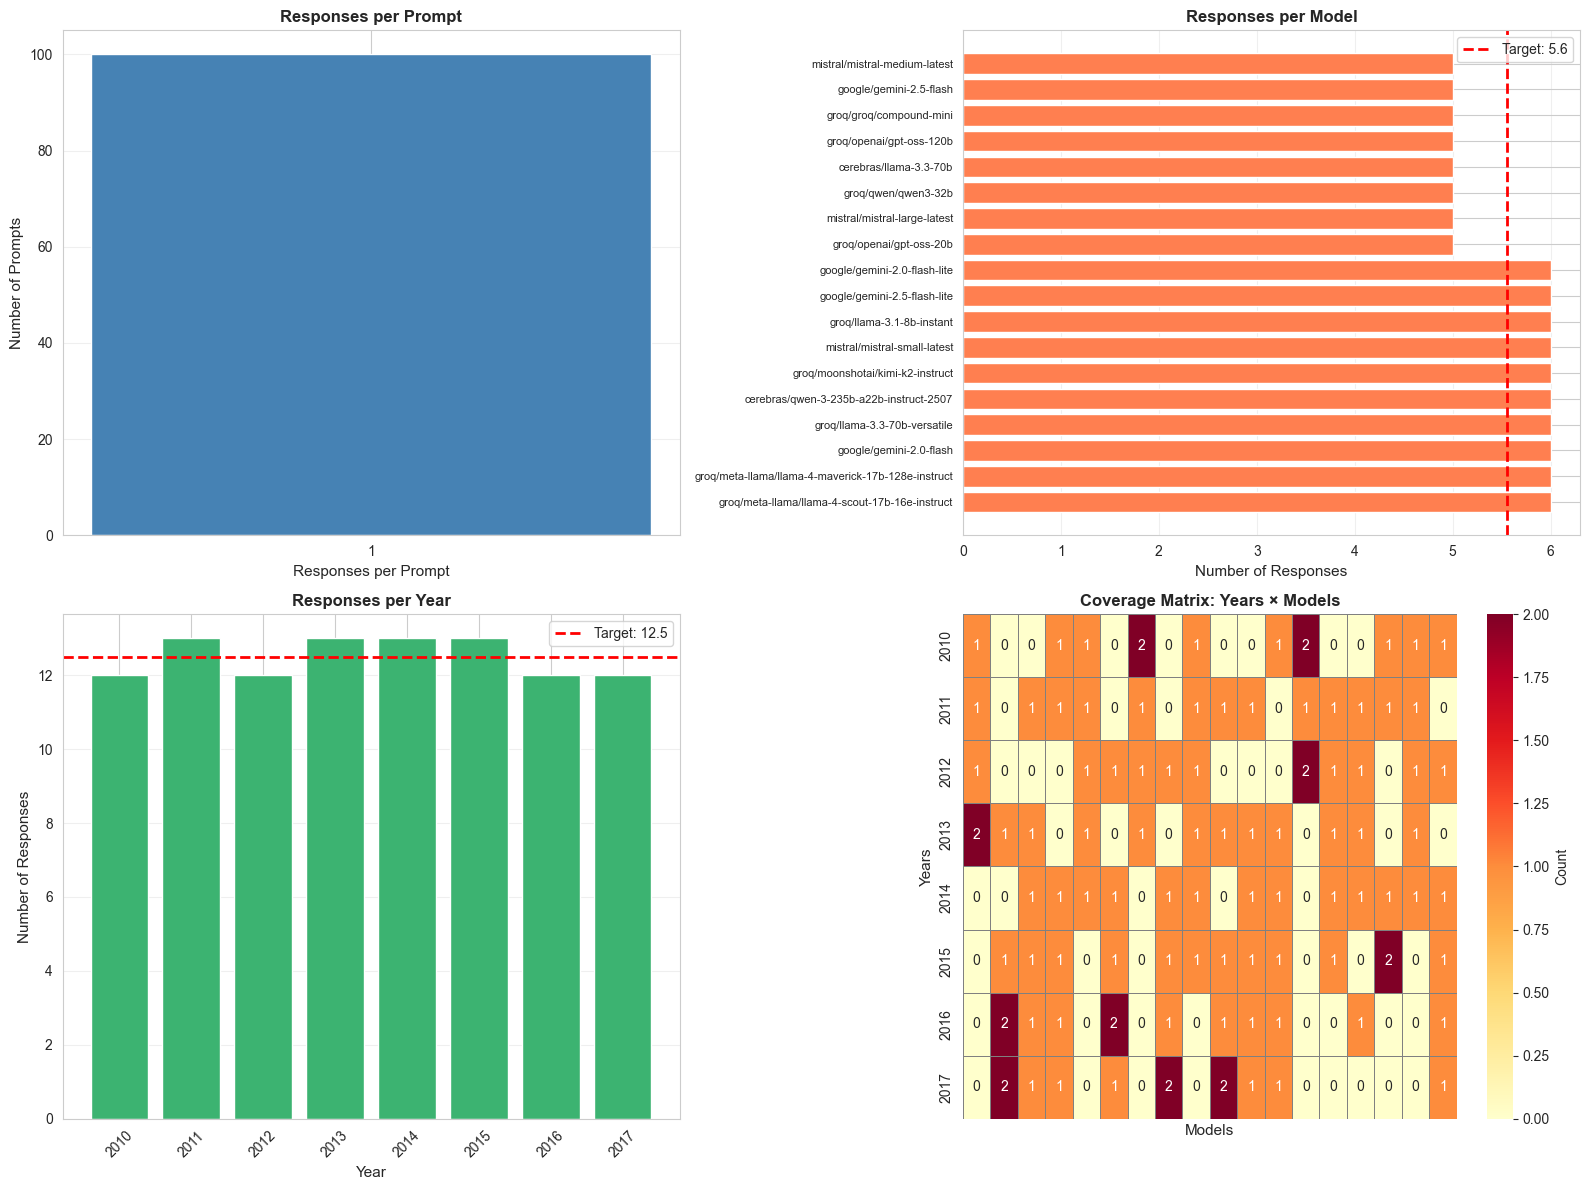

In [102]:
# Comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prompt distribution
prompt_dist = df_selected['prompt_id'].value_counts()
count_dist = prompt_dist.value_counts().sort_index()
axes[0, 0].bar(count_dist.index.astype(str), count_dist.values, color='steelblue')
axes[0, 0].set_title("Responses per Prompt", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Responses per Prompt", fontsize=11)
axes[0, 0].set_ylabel("Number of Prompts", fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)

# Model distribution
model_dist = df_selected['model_id'].value_counts().sort_values(ascending=False)
axes[0, 1].barh(range(len(model_dist)), model_dist.values, color='coral')
axes[0, 1].set_yticks(range(len(model_dist)))
axes[0, 1].set_yticklabels(model_dist.index, fontsize=8)
axes[0, 1].axvline(target_per_model, color='red', linestyle='--', linewidth=2, label=f'Target: {target_per_model:.1f}')
axes[0, 1].set_title("Responses per Model", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Number of Responses", fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(axis='x', alpha=0.3)

# Year distribution
year_dist = df_selected['year'].value_counts().sort_index()
axes[1, 0].bar(year_dist.index.astype(str), year_dist.values, color='mediumseagreen')
axes[1, 0].axhline(target_per_year, color='red', linestyle='--', linewidth=2, label=f'Target: {target_per_year:.1f}')
axes[1, 0].set_title("Responses per Year", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Year", fontsize=11)
axes[1, 0].set_ylabel("Number of Responses", fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Year × Model heatmap
if 'year' in df_selected.columns and 'model_id' in df_selected.columns:
    coverage = df_selected.groupby(['year', 'model_id']).size().unstack(fill_value=0)
    if len(coverage) > 0 and len(coverage.columns) > 0:
        coverage_sorted = coverage.sort_index(axis=0).sort_index(axis=1)
        sns.heatmap(
            coverage_sorted,
            annot=True,
            fmt='d',
            cmap='YlOrRd',
            cbar_kws={'label': 'Count'},
            linewidths=0.5,
            linecolor='gray',
            ax=axes[1, 1],
            xticklabels=False,
            yticklabels=True
        )
        axes[1, 1].set_title("Coverage Matrix: Years × Models", fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel("Models", fontsize=11)
        axes[1, 1].set_ylabel("Years", fontsize=11)
    else:
        axes[1, 1].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[1, 1].set_title("Coverage Matrix", fontsize=12, fontweight='bold')
else:
    axes[1, 1].text(0.5, 0.5, 'No year data', ha='center', va='center')
    axes[1, 1].set_title("Coverage Matrix", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## Additional Statistics


In [103]:
# Additional Statistics
prompt_dist = df_selected['prompt_id'].value_counts()
print(f"Prompt distribution:")
print(f"  1 response: {(prompt_dist == 1).sum()} prompts")
print(f"  2 responses: {(prompt_dist == 2).sum()} prompts")
print(f"  Total unique: {len(prompt_dist)}")

if 'year' in df_selected.columns:
    year_dist = df_selected['year'].value_counts().sort_index()
    print(f"\nYear distribution:")
    for year, count in year_dist.items():
        print(f"  {year}: {count} ({count/len(df_selected)*100:.1f}%)")


Prompt distribution:
  1 response: 100 prompts
  2 responses: 0 prompts
  Total unique: 100

Year distribution:
  2010: 12 (12.0%)
  2011: 13 (13.0%)
  2012: 12 (12.0%)
  2013: 13 (13.0%)
  2014: 13 (13.0%)
  2015: 13 (13.0%)
  2016: 12 (12.0%)
  2017: 12 (12.0%)


## Generate Run File Format

Convert selected records to the labeling platform run format (compatible with --run-file CLI).


In [104]:
# Generate run file format for labeling platform
grid_map = {row.get('prompt_id'): row for _, row in df_grid.iterrows() if row.get('prompt_id')}

# Use unique run_id to prevent overwriting existing data
unique_run_id = f"run_{RUN_HASH}_sampled"

run_records = []
for _, row in df_selected.iterrows():
    prompt_id = str(row['prompt_id'])
    model_id = str(row['model_id'])
    # Dear Abby doesn't have perspective (it's null)
    perspective = row.get('perspective', None)
    
    # Get messages from grid_map if available, otherwise from row
    if prompt_id in grid_map:
        messages = grid_map[prompt_id].get('messages', [])
    else:
        messages = row.get('messages', [])
    
    run_records.append({
        "prompt_id": prompt_id,
        "model_id": model_id,
        "response_text": str(row.get('response_text', '')),
        "perspective": perspective,  # Can be None for Dear Abby
        "factors": row.get('factors'),
        "provider": row.get('provider'),
        "messages": messages,
        "run_id": unique_run_id,
    })

print(f"Generated {len(run_records)} run records")
print(f"Run ID: {unique_run_id}")


Generated 100 run records
Run ID: run_f2d3e4b22e01564f_sampled


## Export Results


In [105]:
# Export to JSONL (for DB push)
jsonl_path = run_dir / 'sampled_run.jsonl'
with jsonl_path.open('w', encoding='utf-8') as f:
    for record in run_records:
        f.write(json.dumps(record, ensure_ascii=False) + '\n')

print(f"Exported JSONL to: {jsonl_path}")
print(f"  Records: {len(run_records)}")
print(f"  Run ID: {unique_run_id}")

# Export to CSV (for inspection)
csv_records = []
for record in run_records:
    csv_record = {
        'prompt_id': record['prompt_id'],
        'model_id': record['model_id'],
        'year': record.get('factors', {}).get('year', '') if isinstance(record.get('factors'), dict) else '',
        'provider': record.get('provider', ''),
        'run_id': record['run_id'],
        'response_text': record['response_text'][:200] + '...' if len(record['response_text']) > 200 else record['response_text'],
    }
    csv_records.append(csv_record)

df_csv = pd.DataFrame(csv_records)
csv_path = run_dir / 'sampled_run.csv'
df_csv.to_csv(csv_path, index=False)

print(f"Exported CSV to: {csv_path}")
print(f"  Records: {len(csv_records)}")

# Summary
print("\n" + "=" * 80)
print("EXPORT SUMMARY")
print("=" * 80)
print(f"JSONL file: {jsonl_path}")
print(f"CSV file: {csv_path}")
print(f"Total records: {len(run_records)}")
print(f"Run ID: {unique_run_id}")
print(f"\nTo push to database, run:")
print(f"  poetry run python scripts/data_portal.py push --dataset dearabby --run-file {jsonl_path} --apply")
print(f"\nNote: Using unique run_id '{unique_run_id}' ensures data is added without overwriting existing records.")


Exported JSONL to: run_f2d3e4b22e01564f/sampled_run.jsonl
  Records: 100
  Run ID: run_f2d3e4b22e01564f_sampled
Exported CSV to: run_f2d3e4b22e01564f/sampled_run.csv
  Records: 100

EXPORT SUMMARY
JSONL file: run_f2d3e4b22e01564f/sampled_run.jsonl
CSV file: run_f2d3e4b22e01564f/sampled_run.csv
Total records: 100
Run ID: run_f2d3e4b22e01564f_sampled

To push to database, run:
  poetry run python scripts/data_portal.py push --dataset dearabby --run-file run_f2d3e4b22e01564f/sampled_run.jsonl --apply

Note: Using unique run_id 'run_f2d3e4b22e01564f_sampled' ensures data is added without overwriting existing records.
